In [ ]:
!pip install -U bitsandbytes transformers accelerate captum

In [ ]:
from google.colab import drive, files
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import os
import sys

path = os.getcwd()
while True:
    if 'utils.py' in os.listdir(path):
        if path not in sys.path:
            sys.path.append(path)
        break
    new_path = os.path.dirname(path)
    if new_path == path:
        upload_utils = files.upload()
        break
    path = new_path

import utils
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Global Parameters of Notebook
global_params = {'dataset_type': 'qnli',
                'quantization': '8bit',
                'training_mode': 'few shot 15 examples',
                'model_id': 'meta-llama/Llama-3.1-8B-Instruct'}

# Create checkpoint
checkpoint_path = utils.create_checkpoint_path(params=global_params)

Saving to: /content/drive/MyDrive/eval_checkpoints/checkpoint_qnli_Llama_3.1_8B_Instruct_8bit_few_shot_15_examples.pt


In [ ]:
utils.hf_login("HF_TOKEN")

In [ ]:
# Quantization configuration
quantization_config = BitsAndBytesConfig(
    load_in_8bit=True
)

tokenizer = AutoTokenizer.from_pretrained(global_params['model_id'])
model = AutoModelForCausalLM.from_pretrained(
    global_params['model_id'],
    device_map="auto",
    quantization_config=quantization_config,
    attn_implementation="eager"
    )

# Add padding token to the tokenizer
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

# Change the model to evaluation mode
model.eval()

In [ ]:
files.upload()

Saving qnli_few_shot_example_idx.npy to qnli_few_shot_example_idx.npy


{'qnli_few_shot_example_idx.npy': b"\x93NUMPY\x01\x00v\x00{'descr': '<i8', 'fortran_order': False, 'shape': (15,), }                                                           \n\xb3\x08\x00\x00\x00\x00\x00\x00 \x07\x00\x00\x00\x00\x00\x00\xc3\x14\x00\x00\x00\x00\x00\x00\xf8\x08\x00\x00\x00\x00\x00\x00\xff\x08\x00\x00\x00\x00\x00\x00\x89\x0f\x00\x00\x00\x00\x00\x00\x13\x05\x00\x00\x00\x00\x00\x00\xde\x03\x00\x00\x00\x00\x00\x00\xfc\x06\x00\x00\x00\x00\x00\x00l\x0b\x00\x00\x00\x00\x00\x00H\n\x00\x00\x00\x00\x00\x00w\x11\x00\x00\x00\x00\x00\x00\x07\x11\x00\x00\x00\x00\x00\x00\xe7\x0c\x00\x00\x00\x00\x00\x00\xe9\n\x00\x00\x00\x00\x00\x00"}

In [ ]:
# Lock 15 examples to be used for few shot
# files.upload()
qnli_val = pd.read_csv('qnli_val.csv')
qnli_val["label"] = qnli_val["label"].map({0: "entailment", 1: "not entailment"})

demo_idxs = np.load('qnli_few_shot_example_idx.npy')

k = 15 # Examples to lock
demo_examples = qnli_val.iloc[demo_idxs[:k]]
qnli_val_few_shot = qnli_val.drop(qnli_val.index[demo_idxs])

In [ ]:
demo_examples

In [ ]:
qnli_val_few_shot.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5448 entries, 0 to 5462
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  5448 non-null   object
 1   sentence  5448 non-null   object
 2   label     5448 non-null   object
 3   idx       5448 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 212.8+ KB


In [ ]:
qnli_val_few_shot.head()

,question,sentence,label,idx
0,What came into force after the new constitutio...,"As of that day, the new constitution heralding...",entailment,0
1,What is the first major city in the stream of ...,The most important tributaries in this area ar...,not entailment,1
2,What is the minimum required if you want to te...,In most provinces a second Bachelor's Degree s...,not entailment,2
3,How was Temüjin kept imprisoned by the Tayichi...,The Tayichi'ud enslaved Temüjin (reportedly wi...,entailment,3
4,"What did Herr Gott, dich loben wir become know...","He paraphrased the Te Deum as ""Herr Gott, dich...",not entailment,4


In [ ]:
# Make examples for prompt
prompt_examples = ''
for i in range(len(demo_examples)):
    prompt_examples += f"Example {i+1}\nQuestion: {demo_examples.iloc[i]['question']}\nSentence: {demo_examples.iloc[i]['sentence']}\nAnswer: {demo_examples.iloc[i]['label']} \n\n"

print(prompt_examples)

Example 1
Question: Which of his future general's fathers helped Temüjin escape the Tayichi'ud?
Sentence: The Tayichi'ud enslaved Temüjin (reportedly with a cangue, a sort of portable stocks), but with the help of a sympathetic guard, the father of Chilaun (who later became a general of Genghis Khan), he was able to escape from the ger (yurt) in the middle of the night by hiding in a river crevice.[citation needed]
Answer: entailment 

Example 2
Question: Which well-known general abandoned Jamukha's coalition against Temüjin?
Sentence: Jamukha's assumption of this title was the final breach with Temüjin, and Jamukha formed a coalition of tribes to oppose him.
Answer: not entailment 

Example 3
Question: What local radio station is broadcast by the Corporation from the Pink Palace?
Sentence: The entrance to studio 5 at the City Road complex gave its name to the 1980s music television programme, The Tube.
Answer: not entailment 

Example 4
Question: When are subject committees establishe

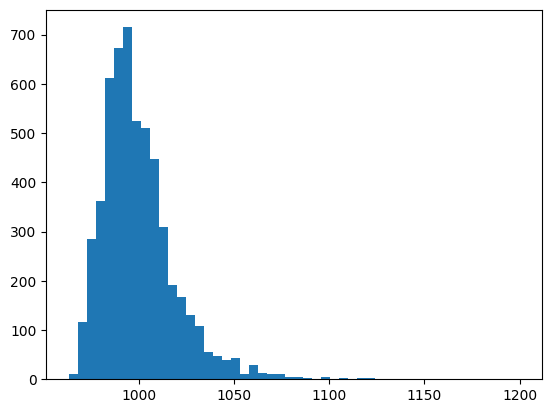

Max prompt length: 1200
Max label length: 3


In [ ]:
# Find the max_length for tokenization to avoid wasting computing.
utils.find_max_length(qnli_val_few_shot, tokenizer=tokenizer, dataset_type=global_params['dataset_type'], examples=prompt_examples)

In [ ]:
prompt_lengths, _ = utils.get_lengths(qnli_val_few_shot, tokenizer, global_params['dataset_type'], examples=prompt_examples)
df = pd.DataFrame(prompt_lengths, columns=["length"])
tokens = 1115 # Max length to check
n = (df["length"] > tokens).sum() # Number of prompts with # > tokens
percent = round(n/len(df)*100, 3)
print(f"Number of examples that have over {tokens} tokens and will be truncated: {n} out of {len(df)} examples or {percent}%")

Number of examples that have over 1115 tokens and will be truncated: 6 out of 5448 examples or 0.11%


In [ ]:
# Define dataset and create a dataloader.
dataset_test = utils.MyDataset_few_shot(dataframe=qnli_val_few_shot,
                                        examples=prompt_examples,
                                        tokenizer=tokenizer,
                                        dataset_type=global_params['dataset_type'],
                                        prompt_max_length=1115,
                                        label_max_length=3)

batch_size = 8 # Change batch size according to GPU
dataloader = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

In [ ]:
# Test
predictions, gold_labels, batch_probs = utils.test_run(model=model,
                                          dataloader=dataloader,
                                          tokenizer=tokenizer,
                                          dataset_type=global_params['dataset_type'])

for i, pair in enumerate(zip(predictions, gold_labels)):
    print(pair, batch_probs[i])

In [ ]:
# Show an example prompt
print(dataset_test[0]['prompt'])

Examples:
Example 1
Question: Which of his future general's fathers helped Temüjin escape the Tayichi'ud?
Sentence: The Tayichi'ud enslaved Temüjin (reportedly with a cangue, a sort of portable stocks), but with the help of a sympathetic guard, the father of Chilaun (who later became a general of Genghis Khan), he was able to escape from the ger (yurt) in the middle of the night by hiding in a river crevice.[citation needed]
Answer: entailment 

Example 2
Question: Which well-known general abandoned Jamukha's coalition against Temüjin?
Sentence: Jamukha's assumption of this title was the final breach with Temüjin, and Jamukha formed a coalition of tribes to oppose him.
Answer: not entailment 

Example 3
Question: What local radio station is broadcast by the Corporation from the Pink Palace?
Sentence: The entrance to studio 5 at the City Road complex gave its name to the 1980s music television programme, The Tube.
Answer: not entailment 

Example 4
Question: When are subject committees 

In [ ]:
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [ ]:
from tqdm import tqdm

# Load checkpoint if it exists
predicted_labels, gold_labels, start_batch = utils.load_checkpoint(checkpoint_path=checkpoint_path)
labels = utils.get_labels(global_params['dataset_type'])

# Loop over the batches
with torch.no_grad():
    for i, batch in enumerate(tqdm(dataloader, desc="Evaluating", unit="batch")):

        # Continue from last checkpoint
        if i < start_batch:
            continue

        input_ids_batch = batch["input_ids"].to(model.device) # Move to GPU
        attention_mask_batch = batch["attention_mask"].to(model.device) # Move to GPU
        gold_labels_batch = batch["labels"] # Keep to CPU

        batch_probs = utils.get_model_probs(batch_input_ids=input_ids_batch,
                                      batch_attention_mask=attention_mask_batch,
                                      dataset_type=global_params['dataset_type'],
                                      model=model,
                                      tokenizer=tokenizer)

        if torch.isnan(batch_probs).any():
            print("Warning: NaNs detected in batch_probs")

        batch_pred_indices = torch.argmax(batch_probs, dim=1)
        batch_pred_labels = [labels[i] for i in batch_pred_indices]

        predicted_labels.extend(batch_pred_labels)
        gold_labels.extend(gold_labels_batch)

        # Save checkpoint
        if i % 50 == 0 or i == len(dataloader) - 1:
            torch.save({"predicted_labels": predicted_labels,
                        "gold_labels": gold_labels,
                        "batch_no": i+1}, checkpoint_path)

            print(f"Checkpoint saved: {i+1}, {checkpoint_path}")

No checkpoint found.


Evaluating:   0%|          | 0/681 [00:00<?, ?batch/s]/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
Evaluating:   0%|          | 1/681 [00:08<1:33:57,  8.29s/batch]

Checkpoint saved: 1, /content/drive/MyDrive/eval_checkpoints/checkpoint_qnli_Llama_3.1_8B_Instruct_8bit_few_shot_15_examples.pt


Evaluating:   7%|▋         | 51/681 [06:44<1:23:16,  7.93s/batch]

Checkpoint saved: 51, /content/drive/MyDrive/eval_checkpoints/checkpoint_qnli_Llama_3.1_8B_Instruct_8bit_few_shot_15_examples.pt


...

Checkpoint saved: 601, /content/drive/MyDrive/eval_checkpoints/checkpoint_qnli_Llama_3.1_8B_Instruct_8bit_few_shot_15_examples.pt


Evaluating:  96%|█████████▌| 651/681 [1:25:57<03:58,  7.94s/batch]

Checkpoint saved: 651, /content/drive/MyDrive/eval_checkpoints/checkpoint_qnli_Llama_3.1_8B_Instruct_8bit_few_shot_15_examples.pt


Evaluating: 100%|██████████| 681/681 [1:29:55<00:00,  7.92s/batch]

Checkpoint saved: 681, /content/drive/MyDrive/eval_checkpoints/checkpoint_qnli_Llama_3.1_8B_Instruct_8bit_few_shot_15_examples.pt


Saving to: /Users/giorgosdikaios/Library/Mobile Documents/com~apple~CloudDocs/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Llama_3.1_8B_Instruct/Few-Shot/checkpoint_qnli_Llama_3.1_8B_Instruct_8bit_few_shot_1_examples.pt
Checkpoint found.
Saving to: /Users/giorgosdikaios/Library/Mobile Documents/com~apple~CloudDocs/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Llama_3.1_8B_Instruct/Few-Shot/checkpoint_qnli_Llama_3.1_8B_Instruct_8bit_few_shot_1_examples.pt
Checkpoint found.
Saving to: /Users/giorgosdikaios/Library/Mobile Documents/com~apple~CloudDocs/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Llama_3.1_8B_Instruct/Few-Shot/checkpoint_qnli_Llama_3.1_8B_Instruct_8bit_few_shot_2_examples.pt
Checkpoint found.
Saving to: /Users/giorgosdikaios/Library/Mobile Documents/com~apple~CloudDocs/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Llama_3.1_8B_Instruct/Few-Shot/checkpoint_qnli_Llama_3.1_8B_Instruct_8bit_few_shot_3_examples.pt
Checkpoint found.


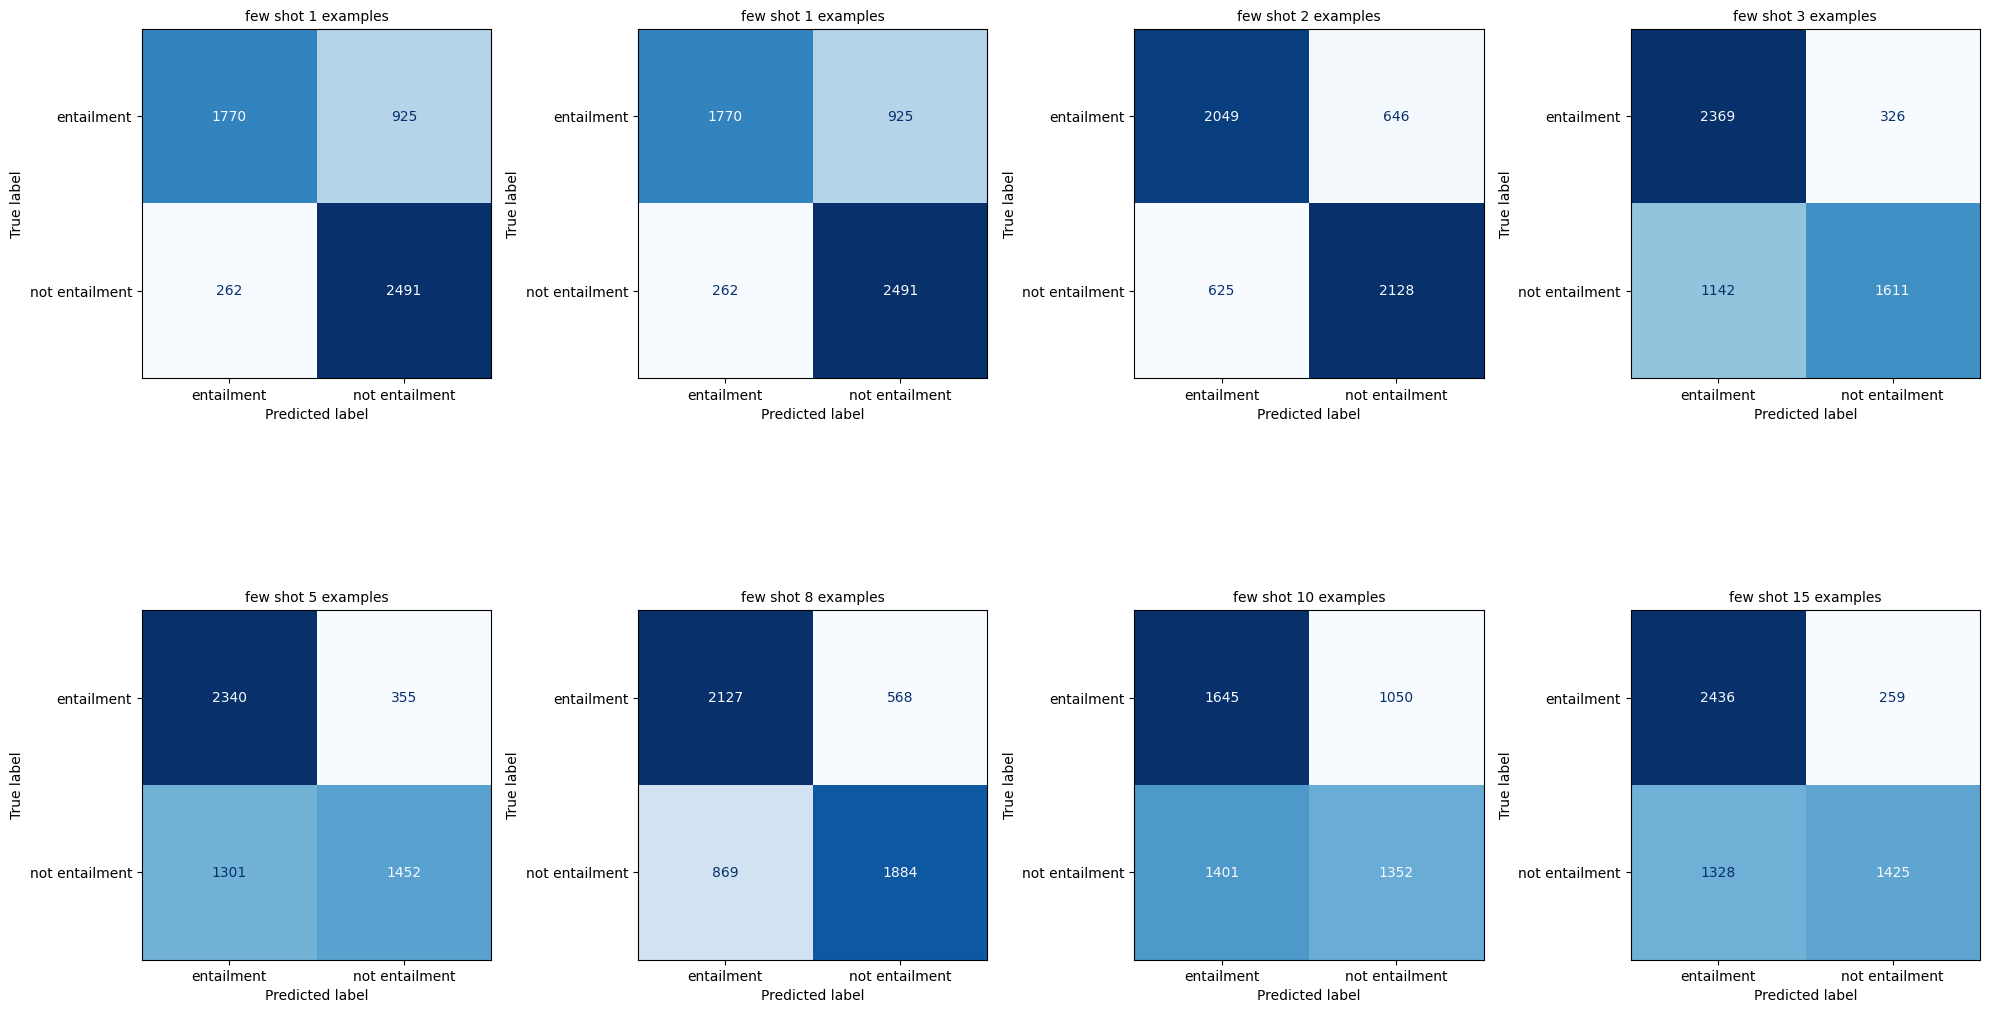

In [3]:
import matplotlib.pyplot as plt

examples_no = [1, 2, 3, 5, 8, 10, 15]
fig, axes = plt.subplots(2, 4, figsize=(20,12))
axes = axes.flatten()
accs, precisions, recalls, f1s, mccs, kappas = [], [], [], [], [], []

idx = 0
for k in examples_no:
    global_params = {'dataset_type': 'qnli',
                    'quantization': '8bit',
                    'training_mode': f'few shot {k} examples',
                    'model_id': 'meta-llama/Llama-3.1-8B-Instruct'}

    checkpoint_path = utils.create_checkpoint_path(params=global_params)
    predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

    acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                            predicted_labels=predicted_labels,
                                            gold_labels=gold_labels,
                                            params=global_params,
                                            ax=axes[idx]
                                            )   
    accs.append(round(acc, 4))
    precisions.append(round(precision, 4))
    recalls.append(round(recall, 4))
    f1s.append(round(f1, 4))
    mccs.append(round(mcc, 4))
    kappas.append(round(kappa, 4))

    idx += 1

    if k == 1:
        global_params = {'dataset_type': 'qnli',
                        'quantization': '8bit',
                        'training_mode': f'few shot {k} examples',
                        'model_id': 'meta-llama/Llama-3.1-8B-Instruct'}

        checkpoint_path = utils.create_checkpoint_path(params=global_params)
        predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

        acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                                predicted_labels=predicted_labels,
                                                gold_labels=gold_labels,
                                                params=global_params,
                                                ax=axes[idx]
                                                )   
        accs.append(round(acc, 4))
        precisions.append(round(precision, 4))
        recalls.append(round(recall, 4))
        f1s.append(round(f1, 4))
        mccs.append(round(mcc, 4))
        kappas.append(round(kappa, 4))

        idx += 1


plt.tight_layout()
plt.show()

In [4]:
idx = [f"{k} examples" for k in examples_no]
idx.append("1 examples opposite")

metrics_df = pd.DataFrame(
    {"Accuracy": accs,
     "Precision": precisions,
     "Recalls": recalls,
    "F1": f1s,
    "MCC": mccs,
    "Kappa": kappas},
    index= idx
)
metrics_df

,Accuracy,Precision,Recalls,F1,MCC,Kappa
1 examples,0.7821,0.8001,0.7808,0.7782,0.5806,0.5631
2 examples,0.7821,0.8001,0.7808,0.7782,0.5806,0.5631
3 examples,0.7667,0.7667,0.7666,0.7667,0.5333,0.5333
5 examples,0.7305,0.7532,0.7321,0.7252,0.4849,0.4627
8 examples,0.6960,0.7231,0.6978,0.6877,0.4202,0.3942
10 examples,0.7362,0.7391,0.7368,0.7357,0.4759,0.4730
15 examples,0.5501,0.5515,0.5507,0.5488,0.1022,0.1014
1 examples opposite,0.7087,0.7467,0.7108,0.6983,0.4560,0.4198


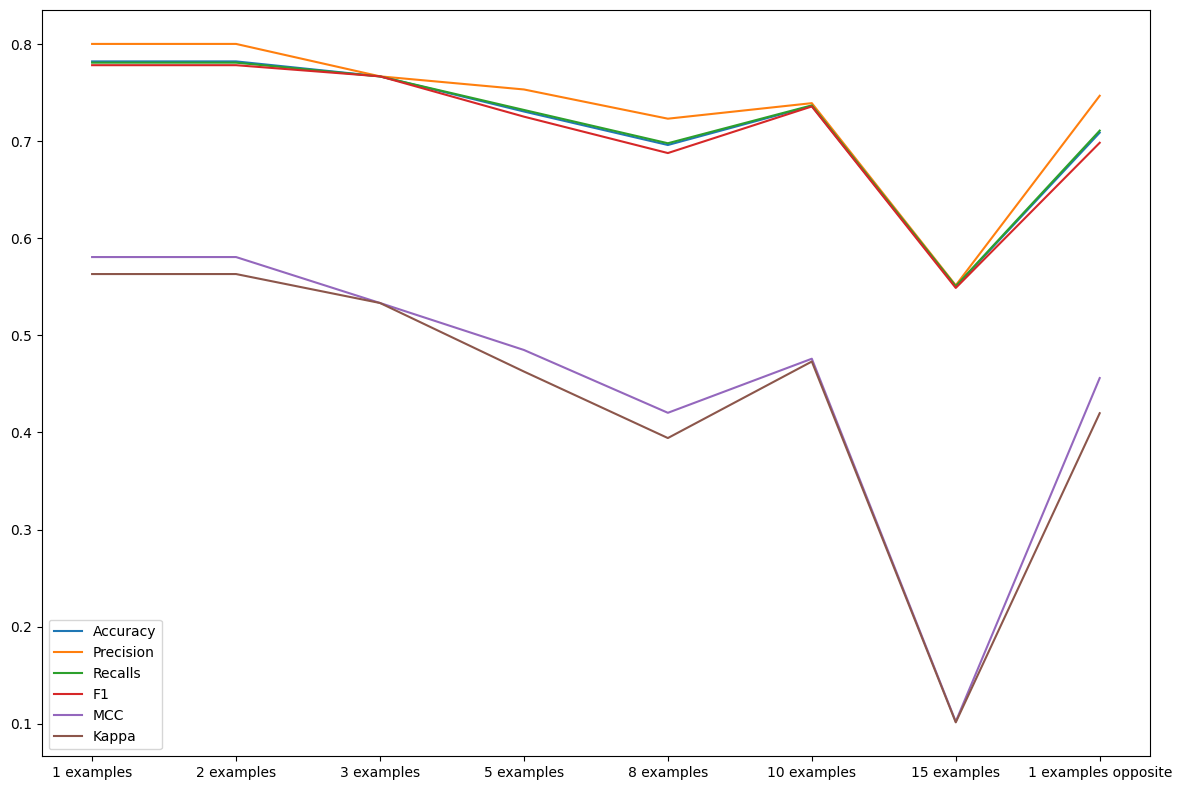

In [5]:
fig, ax = plt.subplots(figsize=(12, 8))
metrics_df.plot(kind='line', ax=ax)
plt.tight_layout()
plt.show()